# <font color="880000"> Econ 196 Seminar: Quantitative Long-Run Global Economic History </font>

### WEEK 12: May 5: Next Year's Class; Schumpeterian Growth & Political Economy since 1875; The Fermi Paradox; & the Future of Humanity :: As Planned

<2026-05-05-PLANNED-econ-196-last-class>

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

### J. Bradford DeLong :: delong@econ.berkeley.edu brad.delong@gmail.com delong@hey.com :: +1-925-708-0467

----

##### <<https://bcourses.berkeley.edu/courses/1551896>>
##### <<https://braddelong.substack.com/t/quantitative-long-run-global-economic>>
##### <<https://braddelong.substack.com/p/quantitative-long-run-global-economic>>
##### <<https://substack.com/home/post/p-184363836>>

----

* Tu 1-3 Evans 560
* Th 1-3 Zoom

**Course Welcome Email**: <<https://bcourses.berkeley.edu/courses/1551896/discussion_topics/7205916?is_announcement=true>>

Download DeLong 2025-12-27 current working github repository: <<https://datahub.berkeley.edu/hub/user-redirect/git-pull?repo=https://github.com/braddelong/working_20251227&urlpath=lab/tree/working_20251227/>>

<br style="clear: both;">

---
---

# Econ 196 Seminar: Quantitative Long-Run Global Economic History

<p style="text-align: right;">
    <img src="images/delong-picture.png"
     alt="J. Bradford DeLong"
     width="300"
     height="300"
     align="right"
     style="float:right; margin: 0 0 10px 10px;" />
</p>

* WEEK 1: Jan 20: Introduction & Human Population
* WEEK 2: Jan 27: Productivity Levels & Technologies
* WEEK 3: Feb 3: Human Evolution, Effective Population Size, & High Patriarchy.
* WEEK 4: Feb 10: Poor Agrarian-Age Malthusian Societies
* WEEK 5: Feb 17: Societies of Domination: Land & Seaborne Agrarian-Age Empires.
* Feb 24: —INFLUENZA—
* WEEK 6: Mar 3: The post-1500 Imperial-Commercial Age
* Mar 10: Projector down—review discussion...
* WEEK 7: Mar 17: 1875 as the Major Hinge of Human History
* WEEK 8: Mar 31: The British Industrial Revolution; The Post-1870 Growth Explosion; Reversals of Fortune; Quantifying The Prosperity Hockey Stick; 1775-1875 in the "Dover Circle"
* WEEK 9: Apr 7: "Reversals of Fortune": Acemoglu, Johnson, & Robinson's "Colonial Origins..." article...
* WEEK 10: Apr 14: The "Development of Underdevelopment" <- **WHERE WE ARE**
* WEEK 11: Apr 21: The "Development of Underdevelopment" II  
* Apr 28: **NO CLASS**: In Oxford for the Hicks Lecture…
* WEEK 12: May 5: Next Year's Class; Schumpeterian Growth & Political Economy since 1875; The Fermi Paradox; & the Future of Humanity

<br style="clear: both;">

---
---

## 0. Introduction

<<>>

This is an interactive jupyter notebook document.

With what looks to be a permanent and long-run partial moving-online of the university, the already important topic of “data science” seems likely to become even more foundational.  Hence I am going to try to provide you with an introduction—to “data science”, and to the framework we will be using for problem sets that we hope will make things much easier for you and for us…

For reference, you might find it useful to read chapter 3 of the Data 8 textbook: <<http://www.inferentialthinking.com/chapters/03/programming-in-python.html>>. Chapters 1 <<https://www.inferentialthinking.com/chapters/01/what-is-data-science.html>> and 2 <<https://www.inferentialthinking.com/chapters/02/causality-and-experiments.html>> are worth skimming as well...

----
----

## 1. Let Us Begin as We Plan to Go on...

### 1.1. Setup

But we are going to skip this for now

In [3]:
# let us setup our basic python jupyter notebook environment...

# no extra windows for graphs & charts...

%matplotlib inline

# ======

# standard libraries
import pandas as pd             # i want the panda—the python panel data analysis—library...
import numpy as np              # i want the numpy—the numerical python—library...
import matplotlib as mpl        # i want the full matlab-style plotting package...
import matplotlib.pyplot as plt # specifically, i want pyplot from matplotlib—
                                # the python plotting interface module within the 
                                # python matlab-style plotting library
import random as rnd            # i want the standard random-number generation package

# ======
# and a couple more:

!pip install linearmodels             # "!" escqping out to the unix shell; "pip" installs packages
                                      # into the python installation; "import" then calls those
                                      # packages into the interpreter's working intantiation
import statsmodels.api as sm          # simple statistical models
from statsmodels.iolib.summary2 import summary_col   # only need one input-output tool
import linearmodels                   # the principal linear models package
from linearmodels.iv import IV2SLS    # specifically, the instrumental-variables package
from scipy.optimize import curve_fit  # i want a tool to allow me to fit not just lines but curves

# ======

# read in dataframe of guesstimates and guesses for finger exercises
# on the longest-run structure of human economic history

human_history_df = pd.read_feather("data/human_history_df.feather") # read in my dataframe

human_history_df.head(5)        # check to see if everything is as expected

,year,population,income,world_product,year_diff,pop_growth,income_growth,tech_growth,ln_tech,tech_index,ln_population,ln_income,ln_tech_index
0,-73000,0.01,1500.0,15.0,NaN,NaN,NaN,NaN,0.000000,0.001829,-4.605170,7.31322,-6.303747
1,-48000,2.00,1500.0,3000.0,25000.0,0.000212,0.0,0.000106,2.649159,0.025872,0.693147,7.31322,-3.654588
2,-23000,3.00,1500.0,4500.0,25000.0,0.000016,0.0,0.000008,2.851891,0.031687,1.098612,7.31322,-3.451856
3,-13000,4.00,1500.0,6000.0,10000.0,0.000029,0.0,0.000014,2.995732,0.036589,1.386294,7.31322,-3.308015
4,-8000,5.00,1500.0,7500.0,5000.0,0.000045,0.0,0.000022,3.107304,0.040907,1.609438,7.31322,-3.196443


In [5]:
# data manipulation: choose:
# 1. what our data are
# 2. when our plots will start
# 3. when our plots will end
# 4. when we will anchor our simulated counterfactual—what history might have
#    been, had things behaved according to some model that simulates what
#    might alternatively have happened—to actual history
# 5. and tell the computer to remember those choices

# and so we def—define—a function, which has:
# 1. a name
# 2. a list in () of things the computer needs to know (here: (human_history_df, plot_start, plot_end, anchor_year))
# 3. a list of things the function calculates and tells
#    the "resr" of the computer (here: return df, i0)

def build_working_df_and_anchor(human_history_df,
                                plot_start,
                                plot_end,
                                anchor_year):
    """
    Return (df, i0) where df is filtered to [plot_start, plot_end]
    and i0 is the index of the row with year == anchor_year.
    """
    df = human_history_df.copy()
    df = df[(df["year"] >= plot_start) & (df["year"] <= plot_end)].reset_index(drop=True)

    i0_matches = df.index[df["year"] == anchor_year]
    if len(i0_matches) == 0:
        raise ValueError(f"anchor_year {anchor_year} not found in df['year']")
    i0 = int(i0_matches[0])

    return df, i0


In [9]:
# another function: decide on what years to plot

def make_sample_masks(df, initial_year, final_year):
    """
    Return boolean masks for in-sample, before-sample, after-sample.
    """
    in_sample = (df["year"] >= initial_year) & (df["year"] <= final_year)
    before_sample = df["year"] < initial_year
    after_sample = df["year"] > final_year
    return in_sample, before_sample, after_sample


In [6]:
# another function: this one to print the results of our estimations:

def report_estimation_results(initial_year, final_year,
                              alpha_hat, sigma_hat,
                              se_alpha, se_sigma,
                              n_obs):
    """
    Pretty-print estimation results for the growth law.
    """
    print(f"Estimation window: {initial_year} to {final_year}")
    print(f"  alpha_hat = {alpha_hat:.6e}  (SE {se_alpha:.2e})")
    print(f"  sigma_hat = {sigma_hat:.4f}  (SE {se_sigma:.4f})")
    print(f"  N obs     = {n_obs}")


In [7]:
# another function: to estimate our equation trying to fit all human history
# into a very narrow straitjacket

def fit_growth_law(df, initial_year, final_year):
    """
    Estimate g_t = alpha * P_t^sigma on [initial_year, final_year].
    Returns (alpha_hat, sigma_hat, se_alpha, se_sigma).
    """
    est_window = (df["year"] >= initial_year) & (df["year"] <= final_year)
    est_df = df.loc[est_window].copy()
    if est_df.empty:
        raise ValueError(f"No data in estimation window {initial_year} to {final_year}")

    P = est_df["population"].to_numpy(dtype=float)
    g = est_df["tech_growth"].to_numpy(dtype=float)

    def g_model(P, alpha, sigma):
        return alpha * (P ** sigma)

    alpha_init = 1e-5
    sigma_init = 0.3
    popt, pcov = curve_fit(g_model, P, g, p0=[alpha_init, sigma_init], maxfev=10000)
    alpha_hat, sigma_hat = popt
    se_alpha, se_sigma = np.sqrt(np.diag(pcov))
    return alpha_hat, sigma_hat, se_alpha, se_sigma


In [8]:
# another function: to compute the simulated fitted values of the level of human "technology"

def compute_H_hat(df, i0, g_col="g_hat", tech_col="tech_index"):
    """
    Construct H_hat by integrating the growth rate g_hat forward and backward
    from anchor index i0.
    """
    H0 = df.loc[i0, tech_col]
    H_hat = np.full(len(df), np.nan)
    H_hat[i0] = H0

    # forward in time
    for i in range(i0 + 1, len(df)):
        dt = df.loc[i, "year"] - df.loc[i - 1, "year"]
        H_hat[i] = H_hat[i - 1] * np.exp(df.loc[i, g_col] * dt)

    # backward in time
    for i in range(i0 - 1, -1, -1):
        dt = df.loc[i + 1, "year"] - df.loc[i, "year"]
        H_hat[i] = H_hat[i + 1] / np.exp(df.loc[i + 1, g_col] * dt)

    df = df.copy()
    df["H_hat"] = H_hat
    return df


In [11]:
# another function: to plot the tech-level results

def plot_tech_level(df, in_sample, before_sample, after_sample, ax=None):
    """
    Plot actual tech_index and fitted/extrapolated H_hat on log scale.
    """
    if ax is None:
        ax = plt.gca()

    valid = (df["tech_index"] > 0) & (df["H_hat"] > 0)

    ax.semilogy(df.loc[valid, "year"], df.loc[valid, "tech_index"],
                "ko-", markersize=5, linewidth=1.5,
                label="Actual H", zorder=3)

    fit_valid = valid & in_sample
    ax.semilogy(df.loc[fit_valid, "year"], df.loc[fit_valid, "H_hat"],
                "b--", linewidth=2, label="Fitted H_hat")

    ext_before = valid & before_sample
    if ext_before.any():
        ax.semilogy(df.loc[ext_before, "year"], df.loc[ext_before, "H_hat"],
                    "r:", linewidth=2, label="Extrapolated H_hat (before)")

    ext_after = valid & after_sample
    if ext_after.any():
        ax.semilogy(df.loc[ext_after, "year"], df.loc[ext_after, "H_hat"],
                    "r--", linewidth=2, label="Extrapolated H_hat (after)")

    ax.set_xlabel("Year")
    ax.set_ylabel("Tech Index H (log scale)")
    ax.set_title("Tech Level: Actual vs Model")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


In [10]:
# another function: to plot the tech-growth rate results

def plot_tech_growth(df, in_sample, before_sample, after_sample,
                     alpha_hat, sigma_hat, initial_year, final_year, ax=None):
    """
    Plot actual tech_growth and fitted/extrapolated g_hat.
    """
    if ax is None:
        ax = plt.gca()

    ax.plot(df["year"], df["tech_growth"],
            "ko-", markersize=5, linewidth=1.5,
            label="Actual tech_growth", zorder=3)

    ax.plot(df.loc[in_sample, "year"], df.loc[in_sample, "g_hat"],
            "b--", linewidth=2,
            label=f"Fitted ({initial_year} to {final_year})")

    if before_sample.any():
        ax.plot(df.loc[before_sample, "year"], df.loc[before_sample, "g_hat"],
                "r:", linewidth=2,
                label=f"Extrapolated (before {initial_year})")

    if after_sample.any():
        ax.plot(df.loc[after_sample, "year"], df.loc[after_sample, "g_hat"],
                "r--", linewidth=2,
                label=f"Extrapolated (after {final_year})")

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_ylabel("Tech growth rate g")
    ax.set_title(
        f"Tech Growth Rate:  α̂={alpha_hat:.3e},  σ̂={sigma_hat:.3f}"
        f"  (est. {initial_year} to {final_year})"
    )
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


In [4]:
# the main function: our traffic cop

def estimate_alpha_sigma(human_history_df=human_history_df,
                         initial_year=-5000, final_year=200,
                         plot_start=-13000, plot_end=2025,
                         anchor_year=200, show_plot=False,
                         show_results=True):
    """
    High-level driver: estimation + fitted g_hat + H_hat + plots.
    """

    # 0. Working df and anchor index
    df, i0 = build_working_df_and_anchor(
        human_history_df, plot_start, plot_end, anchor_year
    )

    # 1. Estimate alpha, sigma
    alpha_hat, sigma_hat, se_alpha, se_sigma = fit_growth_law(
        df, initial_year, final_year
    )

    # 2. Build g_hat everywhere
    df["g_hat"] = alpha_hat * (df["population"].to_numpy(dtype=float) ** sigma_hat)

    # 3. Integrate to H_hat
    df = compute_H_hat(df, i0)

    # 4. Masks + plots
    in_sample, before_sample, after_sample = make_sample_masks(df, initial_year, final_year)

    if show_plot:
        fig, axes = plt.subplots(2, 1, figsize=(12, 10))
        plot_tech_growth(df, in_sample, before_sample, after_sample,
                         alpha_hat, sigma_hat, initial_year, final_year,
                         ax=axes[0])
        plot_tech_level(df, in_sample, before_sample, after_sample,
                        ax=axes[1])
        plt.tight_layout()
        plt.show()

    if show_results:
        n_obs = int(((df["year"] >= initial_year) & (df["year"] <= final_year)).sum())
        report_estimation_results(initial_year, final_year,
                                  alpha_hat, sigma_hat,
                                  se_alpha, se_sigma,
                                  n_obs)
        
    return alpha_hat, sigma_hat, df



### 1.2. Let Us Do Something!

1. Consider the path followed by human history from the year -5000 to the year 200
2. See what simple growth law would fit those years
3. Estimate the parameters of that growth law
4. See how well it does outside of its fitted domain

----

In [79]:
# import our data—our guesstimates, rather:

human_history_df = pd.read_feather("data/human_history_df.feather") # read in my dataframe

In [80]:
# and look at it:

print(human_history_df[["year", "population", "income", "tech_index"]])
print(" ")
print("Note: ")
print("    population in millions;")
print("    income is average annual per capita income, on a 'capability")
print("    to produce necessities and simple conveniences' basis;")
print("    tech_index is proportional to income times the square root of population.")

     year  population   income  tech_index
0  -73000        0.01   1500.0    0.001829
1  -48000        2.00   1500.0    0.025872
2  -23000        3.00   1500.0    0.031687
3  -13000        4.00   1500.0    0.036589
4   -8000        5.00   1500.0    0.040907
5   -5000       19.00   1100.0    0.058478
6   -3000       45.00   1100.0    0.089996
7   -1500       91.00   1100.0    0.127979
8    -600      150.00   1100.0    0.164310
9     200      260.00   1100.0    0.216324
10    800      200.00   1100.0    0.189729
11   1300      430.00   1200.0    0.303488
12   1500      450.00   1400.0    0.362210
13   1600      500.00   1450.0    0.395439
14   1700      610.00   1525.0    0.459368
15   1775      800.00   1600.0    0.551939
16   1825     1100.00   1800.0    0.728107
17   1875     1389.00   2200.0    1.000000
18   1900     1650.00   3400.0    1.684407
19   1925     2000.00   4400.0    2.399904
20   1950     2530.00   5800.0    3.558070
21   1975     4070.00   8900.0    6.924898
22   2000  

In [20]:
# focus on our data from -5000 to 200:

mask = (human_history_df["year"] >= -5000) & (human_history_df["year"] <= 200)

print(human_history_df.loc[mask, ["year", "population", "income", "tech_index"]])

   year  population  income  tech_index
5 -5000        19.0  1100.0    0.058478
6 -3000        45.0  1100.0    0.089996
7 -1500        91.0  1100.0    0.127979
8  -600       150.0  1100.0    0.164310
9   200       260.0  1100.0    0.216324


#### 1.2.1. How Are We to Understand Human History?

* anthology intelligence
* two heads are better than one
* stepping on toes

**Modeling Rates of Technological Progress**: It was, I think, in 1985 back when I was still a graduate student that I really became aware of the "two heads are better than one" argument, as I sat on the top floor of the Parker House hotel in Botston and watched Paul Romer present a piece of his dissertation—a piece that had already been accepted by and was about to be published in the _Journal of Political Economy_. 

* **Romer, Paul M.** 1986. “Increasing Returns & Long-Run Growth.” _Journal of Political Economy_ 94(5): 1002–37. <<https://paulromer.net/speeding-up-and-missed-opportunities-evidence/IncreasingReturns.pdf>>.
* **Kremer, Michael.** 1993. “Population Growth & Technological Change: One Million B.C. to 1990.” _Quarterly Journal of Economics_ 108 (3): 681–716. <<https://faculty.econ.ucdavis.edu/faculty/gclark/210a/readings/kremer1993.pdf>>>
* **Diamond, Jared.** 1997. _Guns, Germs, and Steel: The Fates of Human Societies_. New York: W. W. Norton. <<https://dn721503.ca.archive.org/0/items/fp_Jared_Diamond-Guns_Germs_and_Steel/Jared_Diamond-Guns_Germs_and_Steel.pdf>>.

Paul did something that, in retrospect, is stunningly simple: he took the old production function, pulled ideas out of the undifferentiated capital aggregate, and insisted that they were different—non-rival, accumulating, and capable of generating increasing returns at the social level even when private firms still faced diminishing returns.

Once you see that, you cannot unsee it. Non-rivalry means that if I have the blueprint for the Watt steam engine or for CRISPR, my using it does not prevent you from using it as well. We can both plug the same idea into our production lines, and the marginal cost of your adoption is, essentially, zero. A world made up only of rival goods—land, raw labor, iron ore—grinds against diminishing returns and the Malthusian devil. Add a stock of non-rival ideas that can be copied and recombined, and suddenly the growth rate of knowledge seems likely, in the simplest possible reduced form, as proportional to the number of brains available to think.

That is where Michael Kremer enters, walking onstage from the long run of one million B.C. to 1990. Kremer basically says: take Romer’s “two heads are better than one” literally and push it back nearly to Homo erectus with a sharp stick. If ideas are non-rival, more people mean more potential inventors. Combine that with a Malthusian world in which population is limited by technology, and you get the striking empirical regularity Kremer documents: for most of human history, the growth rate of population is roughly proportional to the level of population. More people → more ideas → higher carrying capacity → more people. A feedback loop, not a steady state.

Jared Diamond gives us the spatial counterpart to this temporal story. Geography, crops, domesticable animals, and continental axes determine where dense populations, cities, and written traditions can form. Those are precisely the institutions that let a society store, copy, and recombine non-rival ideas at scale. An Andean herder and a Fertile Crescent scribe are not different in cognitive capacity; what is different is how many other heads their ideas can bump up against, how many previous ideas they can draw on, and how cheaply those ideas can be transmitted.

Now we want to immediately start complicating this "two heads are better than one" story further, adding one crucial wrinkle: “stepping on toes”. In a world with limited communication, limited integration, and a lot of parallel, duplicative effort, doubling the number of brains does not double the flow of new, non-redundant ideas. The relationship between population and technological progress is increasing, but less than linear.

That suggests a very simple workhorse model of agrarian-age technological progress as a function of world population:

$$
\begin{equation}
\ h_t = \frac{\dot H_t}{H_t} =  \alpha P_t^\sigma
\end{equation}
$$

where hₜ is the proportional growth rate of the technology index, Pₜ is world population, α is a “two heads are better than one” efficiency parameter, and σ captures the degree of “stepping on toes”—σ = 1 would be perfect non-duplication, σ < 1 means more people help, but with diminishing incremental payoff per added head.

Thus the question is: *what does the history of the agrarian age tell us about α and σ, if we take this to be a reasonable reduced-form description of agrarian-age technological growth?*?

---
---

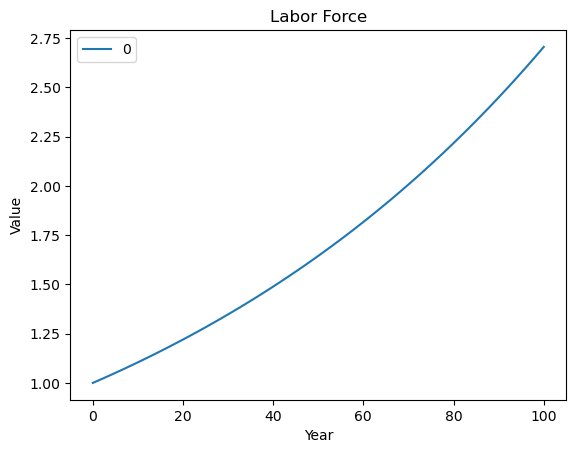

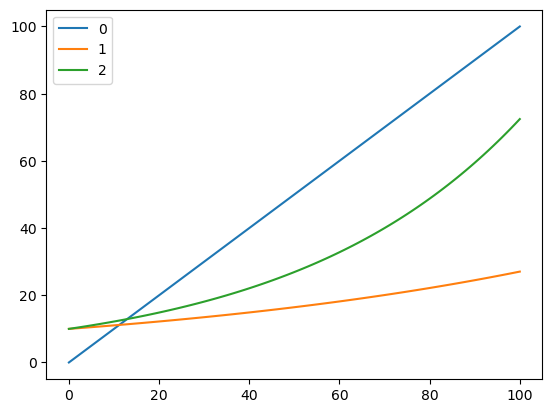

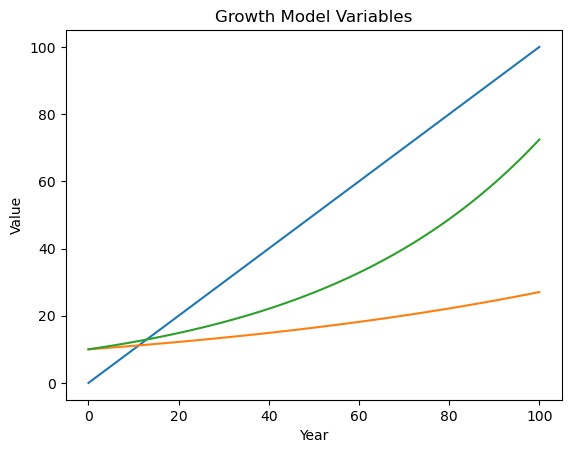

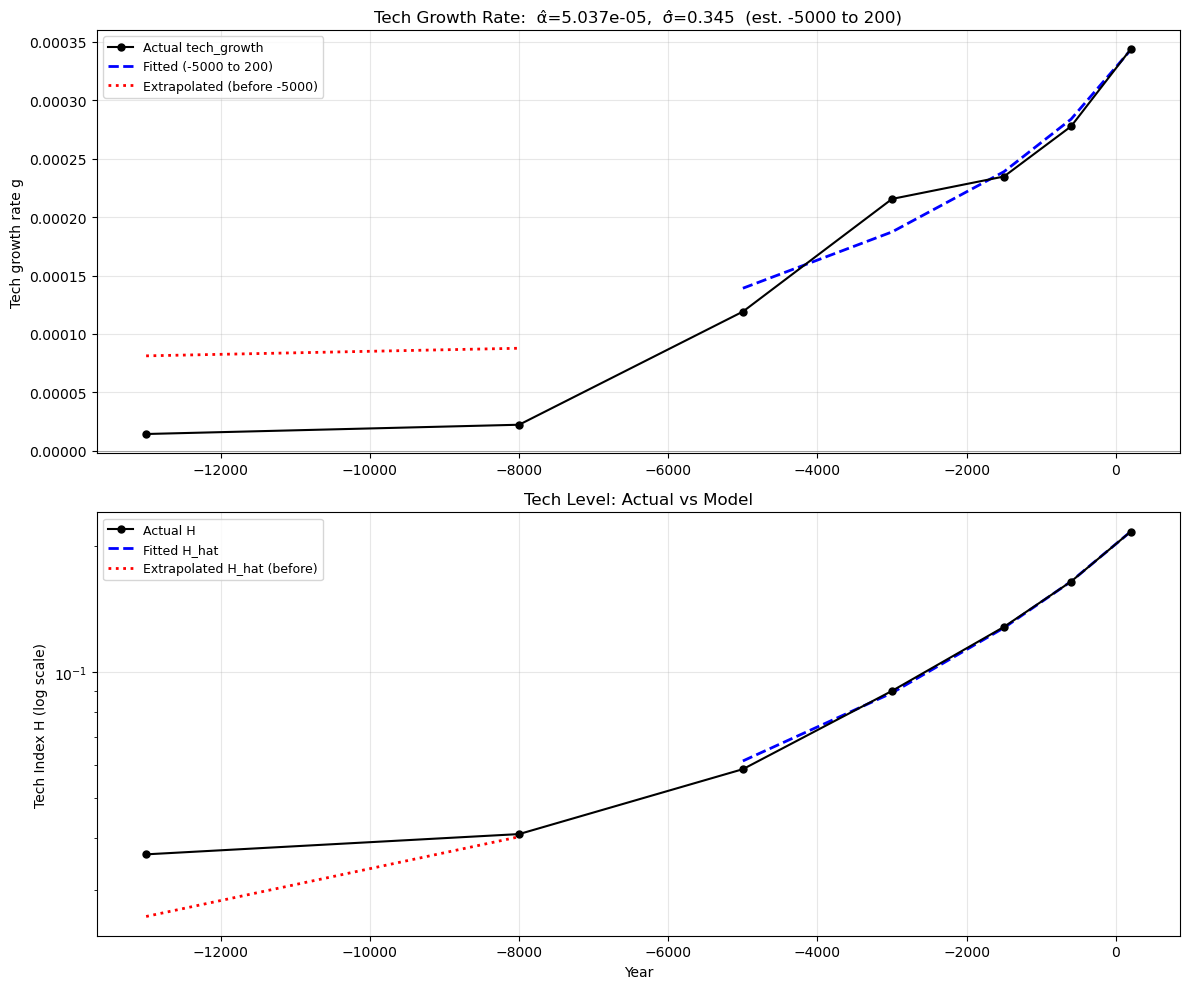

Estimation window: -5000 to 200
  alpha_hat = 5.036827e-05  (SE 1.21e-05)
  sigma_hat = 0.3451  (SE 0.0486)
  N obs     = 5


In [81]:
# estimate_alpha_sigma(initial_year=-5000, final_year=200, plot_start=-13000, plot_end=200, anchor_year=200):


results = estimate_alpha_sigma(initial_year=-5000, final_year=200, 
                               plot_start=-13000, plot_end=200, 
                               anchor_year=200, show_plot=True)

That is:

$$
h_t = \frac{\dot H_t}{H_t} = 0.0000504\, P_t^{0.345}
$$

---

Note that it does not do well before agriculture. The accumulation of ideas was much slower before we had settled down to farm. 

And note that there is a small apparent burst of creativity at the start of the Bronze Age: the coming of bronze tools (and weapons), records, writing, and their bastard offspring of the state, with all of its society of domination, panoply. 

But otherwise, it seems to pretty much nail it. But it is not that two heads are twice as good as one. Instead, it is that two heads are the cube root of two as good as one, i.e.\ $\sqrt[3]{2}$ times as good.

However, when we widen our view things break down:

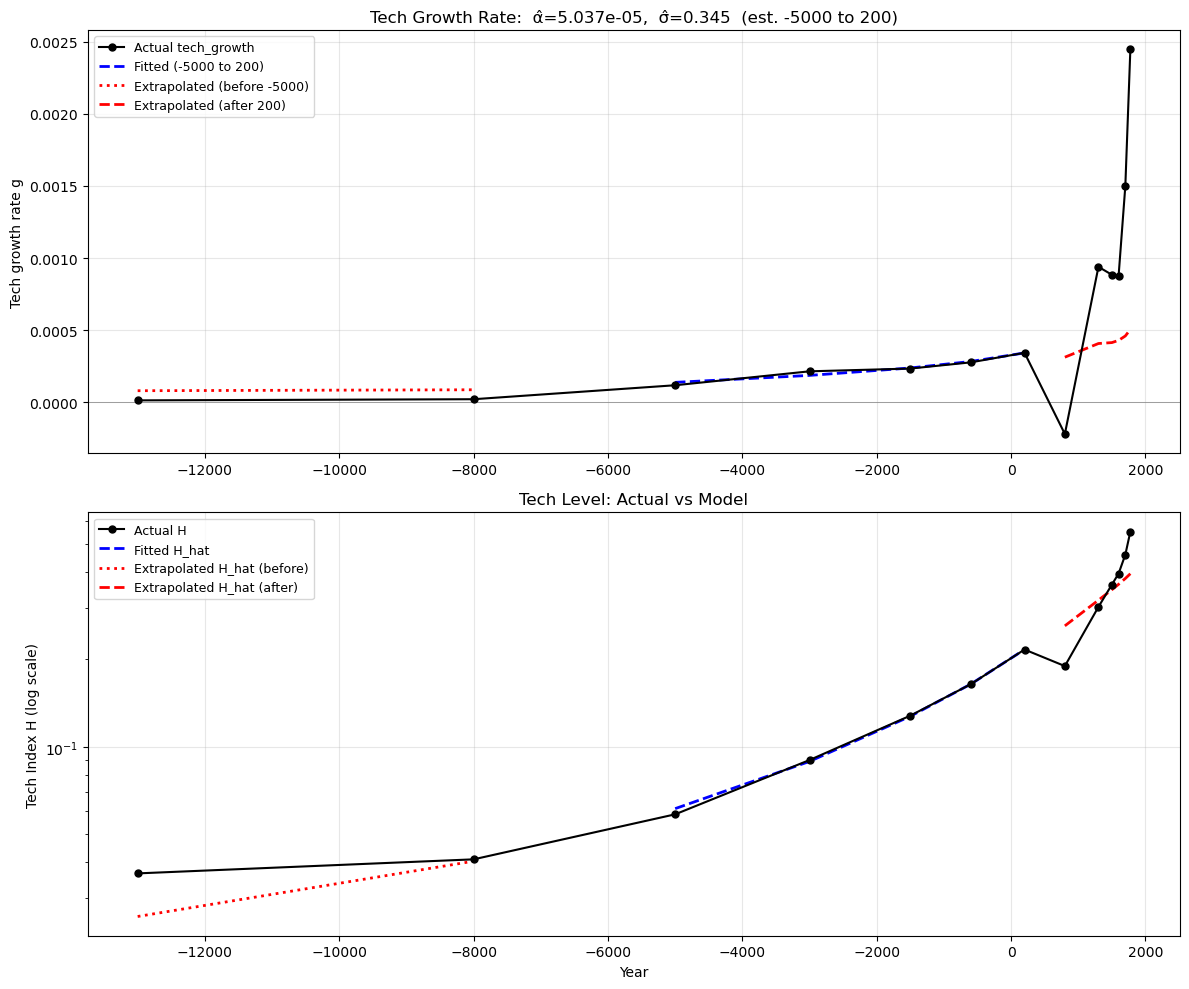

Estimation window: -5000 to 200
  alpha_hat = 5.036827e-05  (SE 1.21e-05)
  sigma_hat = 0.3451  (SE 0.0486)
  N obs     = 5


In [33]:
# estimate_alpha_sigma(initial_year=-5000, final_year=200, plot_start=-13000, plot_end=1775, anchor_year=200):


results = estimate_alpha_sigma(initial_year=-5000, final_year=200, 
                               plot_start=-13000, plot_end=1775, 
                               anchor_year=200, show_plot=True)

We see:

* a Late-Antiquity Pause;
* a Mediæval Catchup; and
* a Commercial-Imperial Age growth acceleration.

---

And when we widen it further: we see—well, one might well call it a "singularity", if one were to adopt the Silicon Valley vibe:

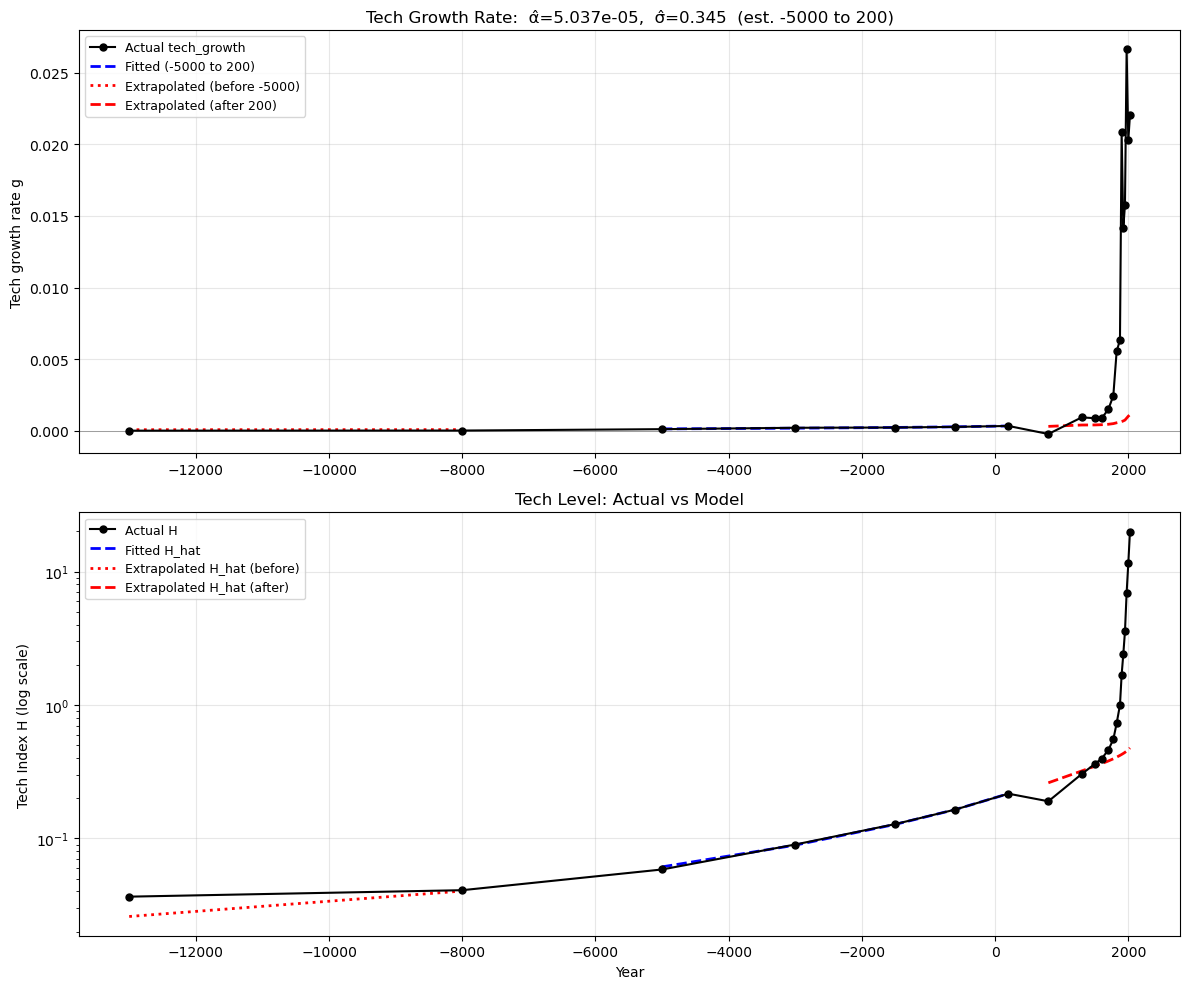

Estimation window: -5000 to 200
  alpha_hat = 5.036827e-05  (SE 1.21e-05)
  sigma_hat = 0.3451  (SE 0.0486)
  N obs     = 5


In [23]:
# estimate_alpha_sigma(initial_year=-5000, final_year=200, plot_start=-13000, plot_end=2025, anchor_year=200):


results = estimate_alpha_sigma(initial_year=-5000, final_year=200, 
                               plot_start=-13000, plot_end=2025, 
                               anchor_year=200, show_plot=True)

We see:

* an Industrial-Revolution explosion; and then the
* Modern Economic Growth miracle.

#### 1.2.2. Further Interpretation

We could have estimated our model over wide different ranges of start and end dates:

<img src="images/2026-03-31-alpha-and-sigma.png" />

checking the fit of 

$$
\begin{equation}
\ h_t = \frac{\dot H_t}{H_t} =  \alpha P_t^\sigma
\end{equation}
$$

for starting years varying from -13000 to the development of writing, bronze, and the state in -3000; and from ending years from the classical-antiquity apogee in the year 200 on up to the start of the industrial revolution century in 1775.

Over what spans of time does this very simple “two heads are better than one, but stepping on toes” story look as if it might actually be a decent reduced form for what is going on in the data, rather than an *ex post* just‑so story? The answer, I think, is: over windows that are recognizably “agrarian” in both their demography and their technology—say, from the late Pleistocene/early Holocene up through classical times, but not for any period that includes history past the year-200 classical-antiquity apogee. When we estimate on windows like −13000 to −600, −13000 to 200, −8000 to −600, −8000 to 200, −5000 to −600, −5000 to 200, or −3000 to −600 and 200, we get α’s that are small but not absurd. We get σ’s that cluster in the ballpark of 0.3 to 0.5. More people do indeed appear to give you more ideas, but with substantial “stepping on toes” diminishing returns: discovery is not proportional to population, but to the square- or cube-root of population.

However, once we push the final year forward into 800 (at the end of the late-antiquity pause), 1300 (the high mediæval world), or 1600 or 1775 (into the commercial-imperial revolution age), however, the model starts vomiting up what we fed it. 

Including 800, we get σ very close to zero (as if population barely matters at all for ideas).

The computer is confronted with a world in technological regress **happened** after 200, but it was not because Pₜ had collapsed—there were still a lot of warm bodies around, The effective technological and organizational infrastructure inherited from classical antiquity suffered a very large negative shock: empires fragmented, long‑distance trade thinned out, cities shrank, literate bureaucracies downshifted to monasteries and courts, and the rate at which useful ideas were recombined and propagated slowed sharply, even as the number of brains available to recombine them remained high by pre‑Holocene standards. 

Trying to shoehorn that episode into a single hₜ = αPₜ^σ relationship is thus asking too much of the model. It tries to cope by declaring that population never mattered much for technology (σ ≈ 0, with α flexing to fit what variance it can).

Historically, what happened between 200 and 800 is not a continuation of “more people, slowly better ideas” but a regime shift in which institutional collapse, geopolitical fragmentation, and the loss (and later, slow reconstruction) of high‑productivity networks dominated the simple combinatorics of headcounts. In that sense, the year‑800 point is useful precisely because it breaks the model: it forces us to recognize that there are negative shocks to the effective idea‑generating and idea‑diffusing machinery—Dark Ages in the literal sense—that the two‑parameters‑and‑a‑power‑law approach cannot hope to capture

Suppose we were to push further, to 1300 or beyond? We get a σ well above one (as if more people lead to more than proportional idea growth). 

It is a fact that after 800 we got faster technological progress by a substantial margin than the -5000 to 200 experience would have led us to expect. Some of this was making up lost ground: redeploying social organization technologies that had vanished after the classical-antiquity apogee. Some of this was that mediæval civilizations were more creative with better potentials for information development than their predecessors. The computer sees these post-800 technological growth rates that are rapid relative to the -13000 to 200 experience, and so desperately reaches for a high value of σ to try to get as close to fitting those anomalous end-of-sample observations as it can. 

From the point of view of Pₜ, this is still recognizably an agrarian world: land is binding, agriculture dominates, cities are small. Population grows, sometimes quite briskly; by 1300 we are, in much of Eurasia, bumping along a relatively high preindustrial carrying capacity. If the simple Kremer story were the whole story—more people, more brains, more ideas—you would expect the 800–1500 centuries to give you parameter estimates that look like a modest extrapolation of the −5000 to 200 regime: σ somewhere between 0 and 1, α small but steady, and hₜ tracking Pₜ with some noise.

That is not what the EDA finds. Once you rope 800–1500 into the window, you are asking the model to digest at least three distinct phenomena with one little hₜ = αPₜ^σ mouthful: the slow post–Dark Age rebuild of Western Europe’s institutional and trade networks; the Mongol shock and its consequences for Eurasian integration; and then, in the back half of the period, the beginnings of what will become the commercial-imperial age, with Venice, Genoa, the Hanseatic League, and their analogues knitting together higher-velocity circuits for goods, people, and ideas. The result is parameter estimates that are telling you, politely but firmly, that population alone is no longer an adequate sufficient statistic for “idea production capacity”. Sometimes σ jumps toward or above 1, with an α so tiny that you are effectively fitting the upturns in hₜ by saying: only at very high Pₜ does this kick in—and even then the scale factor is microscopic. Sometimes σ wants to slide back toward the 0.3–0.5 agrarian comfort zone but can only do so by misfitting the mid-medieval “plateau and push” in your tech index.

In plainer language: 800–1500 is an era in which organizational, institutional, and geopolitical structures—the rise of commercial city-states, the spread of money economies, the (partial) reconstitution of long-distance trade, the beginnings of global exploration and extraction at the very end—start to matter a great deal for how effectively brains get marshaled into useful new ideas. The model thinks in terms of headcounts; the history is increasingly about networks and incentives. The fact that you can get a decent fit over −5000 to 200 and then watch the parameter pair go haywire as you extend the window to 1300 or 1500 is not a bug: it is the data tapping you on the shoulder and saying that by the high medieval period you are no longer in a world where “population → ideas” is the dominant channel. You are in a world where institutions, trade structures, and state systems have begun to amplify—or choke off—the combinatorics of brains in ways that a single power law in Pₜ cannot absorb. As an exploratory device, that is exactly what you want the exercise to do: signal where the simple story runs out of gas, and where you have to start writing down something closer to a political economy of innovation, not just a demography of it.

So the moral is: treat the “two heads, stepping on toes” formulation as a decent reduced form for the long, grinding agrarian ascent up to the classical plateau; once you attempt to absorb the late‑antiquity‑pause and its aftermath, the estimates themselves start waving red flags that you are now in the business of modeling institutional catastrophe and recovery, not just the arithmetic of brains and blueprints.

---
---

## 2. Why Are We Doing This?

Your reaction by now is almost surely: "This is overkill!" 

If so, you are right: this is overkill. We have only about 50 numbers to deal with. And yet we have fired up a substantial automated calculation and presentation apparatus. 

But, out in the real world, you all are going to be faced not with collections of 50 numbers, but collections of 5,000, or 5 million. And you will be helpless in their face if you do not have command of the basic data science EDA tools. 

Starting in 1775, human history underwent a phase shift with the beginnings of the British Industrial Revolution century and the emergence for the first time of GPTs: General Purpose Technologies. The first wave of steam-engine-coupled-to-automatic-textile machinery remade the human economy over the next hundred years. For 4/5 of the economy things get broadly better—potential productivity went up by maybe half—but things remained broadly recognizable. For 1/5 of the economy, things were utterly transformed by the GPT: productivity at the end in that slice affected was perhaps nine times what it had been at the start, but if you insisted in trying to do your job in the old way with the old tools, your income was at most a third that of your predecessors. Joseph Schumpeter called this capitalist creative destruction. He was right. We should probably call it capitalist engineering entrepreneurial creative destruction. But it was a very new thing in human history, and an important thing. 

It was a thing that became much more important after 1875. New GPTs emerged not every half century or so, but every decade, and the tripling of human technological capability took not a century, but rather 37 years or so. We have had four of these episodes since 1875. I call them applied-science, mass-production, globalized value-chain, and now info-bio tech-attention. But there are many other names, and you might here periodizations like: Belle-Époque, Social-Democratic, Neoliberal, and Post-Neoliberal. They are pointing at the same thing from different angles.

For you, personally, the current coming of info-bio tech-attention economy and society is especially noteworthy. Because this time, it is the jobs that you are best suited for that are in the bullseye of the Schumpeterian creative-destruction engineering-entrepreneurial-capitalist GPT process. Adapt. Or else. And a substantial part of your success at adaptation will depend on whether you are able to master the tools of literacy and numeracy in their future form or not. Starting now.

Thus learning jupyter notebooks and python may well turn out to be the intellectual equivalent for you of "eat your spinach": something that may seem unpleasant and unappetizing now, but that makes you stronger and more capable.

A couple of years ago, I had coffee with a student who had graduated in 2007, and who attributed a large chunk of the interesting and successful career he has had in the past decade-and-a-half years—had in spite of the collapse of the job market in 2008—to the fact that he had been fluent in Microsoft Office when he left Berkeley. But now, he said—and I agree—it is not fluency in Word, Powerpoint, and (shudder) Excel that allows one to make oneself useful in a white-collar organization doing interesting work while one learns-by-doing, it is rather fluency in a language like Python and the ability to script hooks into various Big Data and other APIs. 

An analogy: Back in the medieval European university, people would learn the Trivium—the 'trivial' subjects of Grammar (how to write), Rhetoric (how to speak in public), and Logic (how to think coherently)—then they would learn the Quadrivium of Arithmetic, Geometry, Music/Harmony, and Astronomy/Astrology; and last they would learn the advanced and professional subjects: Law or Medicine or Theology and Physics, Metaphysics, and Moral Philosophy.

But a student would also learn two more things: how to learn by reading—how to take a book and get something useful out of it, without a requiring a direct hands-on face-to-face teacher; and (2) how to write a fine chancery hand so that they could prepare their own documents, for submission to secular courts or to religious bishops or even just put them in a form where they would be easily legible to any educated audience back in those days before screens-and-attachments, before screens-and-printers, before typewriters, before printing.

In 1999 Python programming language creator Guido van Rossem compared the ability to read, write, and use software you had built or modified yourself to search and analyze data and information collections. Guido predicted that mass programming, if it could be attained, would produce increases in societal power and changes in societal organization of roughly the same magnitude as mass literacy has had over the past several centuries. Guido may be right, and he may be wrong. But what is clear is that your lives may be richer, and you may have more options, if the data science and basic programming intellectual tools become a useful part of your intellectual panoplies.

The Data Science tools may well turn out to be in the first half of the 2000s the equivalent of a _fine chancery hand_, just as a facility with the document formats and commands of the Microsoft office suite were the equivalent of a fine chancery hand at the end of the 1900s: practical, general skills that make you of immense value to most if not nearly all organizations. This—along with the ability to absorb useful knowledge without requiring hands-on person-to-person face-to-face training—will greatly boost your social power and your set of opportunities in your life.

If we are right about its value.

Why Jupyter and Python, rather than R-studio and R, or C++ and Matlab? 

Because Jupyter Project founder Fernando Perez has an office on the fourth floor of Evans. Because 40% of Berkeley undergraduates currently take Data 8 and so, taking account of other channels, more than half of Berkeley students are already going to graduate literonumerate in Python.

Is fluency in something like Python in particular and data-science tools in general is becoming, for the 21st Century, the equivalent of what learning to write a fine chancery hand was if you went to Oxford or Cambridge University in the 14th Century? We do not know. We do think we should help you get ready.

----

## 3. Jupyter Notebooks

This browser window is now showing you a computer science object that is called a "Jupyter notebook". A notebook is a place to write programs and view their results, and also to write text. The text and programs are contained in little boxes called "cells". When the computer thinks that you are paying attention to a particular cell—and may click in it, and then edit it—it surrounds the cell with a blue box, and puts a blue line to the left of the cell.

A notebook is an editable document object in which you can write computer programs; view their results; and comment, annotate, and explain what is going on. Project jupyter:

<<https://en.wikipedia.org/wiki/Project_Jupyter>> 

is headquartered here at Berkeley, where jupyter originator and ringmaster Fernando Pérez 
<<https://en.wikipedia.org/wiki/Fernando_Pérez_(software_developer)>> 

works: its purpose is to build human-friendly frameworks for interactive computing. If you want to see what Fernando looks and sounds like, you can load and watch a 15-minute inspirational video by clicking on the line 'YouTubeVideo("Wd6a3JIFH0s")' in the cell immediately below this one, and then clicking on the '▶' symbol in the toolbar at the top of the sub-window this cell appears in: 

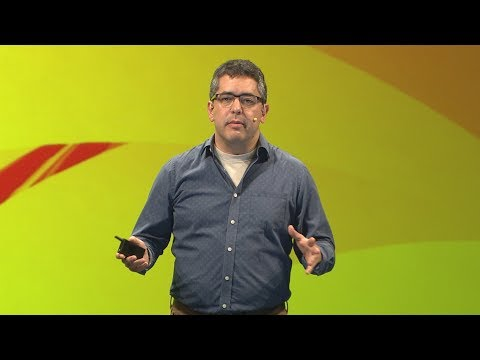

In [34]:
from IPython.display import YouTubeVideo

# The original URL is: 
# https://www.youtube.com/watch?v=Wd6a3JIFH0s

YouTubeVideo("Wd6a3JIFH0s")

### 3.1. Cells & Notebooks

#### 3.1.1. Code Cells

The _cell_ directly below this one contains one line of code in the Python 3 computer language. You _run_ this line as a program—the computer _executes_ the instructions the cell containss—when you click on the '▶' symbol in the toolbar at the top of this sub-window. (You could also have run the cell by, when the computer has focused on it by your clicking on it, pressing 'shift-return' or 'control-return' on your keyboard.) a code cell will execute all of the code it contains.

The line of type in the cell is a _Python expression_.
&nbsp;

Now try running this cell:

In [82]:
print("Hello, world!")

Hello, world!


and this one:

In [83]:
print("\N{WAVING HAND SIGN}, \N{EARTH GLOBE ASIA-AUSTRALIA}!")

👋, 🌏!


Every 'print' expression commands the computer to print a line of symbols to the screen. Directions as to what is in the line of symbols that it prints are contained between the '(' and the ')' that follow the initial Python command 'print' on the expression line.

The first of the two code cells above that you just ran is the standard first computer program to write, either if you are a new student or if you are testing out a new machine or testing out writing in a new programming language. it tells the computer to print out to the screen the symbols 'Hello, World!' What did the second code cell print to the screen, and why?

Within a code cell, each 'print' statement's output is printed to the screen on a separate line. The lines are arranged in the order in which the computer, scanning from the top to the bottom of the code cell, encounters the lines.

----

Remember the Fernando Perez video? Let's look back on its code cell:

This cell tells the computer to enlarge the set of Python commands it understands by finding the `YouTubeVideo` command in the `IPython.display` external library of commands, and then importing that command into its memory. Once it has done that, you can then ask the computer to execute that command—which then constructs a little YouTube video window and plays a YouTube video in it. You ask the computer to do so the in the fourth line of the code cell. Which YouTube video does the computer play? You tell it by writing, after `YouTubVideo` a `(`, then a `"`, then the reference ID of the video, then another `"`, and then, finally, a `'`.

Between the first and the last lines of the code cell are two lines that are _comment lines_. Anything on a line that comes after a `#` symbol inside a code cell the computer takes to be a comment—something directed at humans, and not at computers, that it should ignore. The comment lines tell you—us—what the URL is for the video that the fourth line is going to command the computer to play.

The cell also contains two blank lines. They are just there to give your eyes and brain visual clues to where to look for information, and thus make code cells easier to read.

----

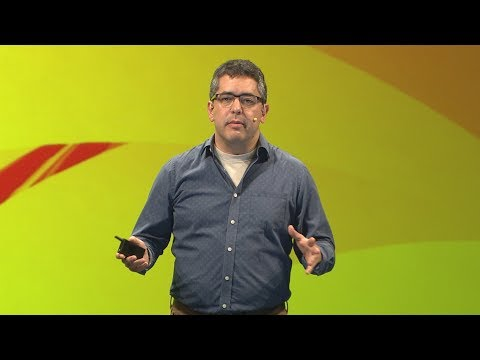

In [84]:
from IPython.display import YouTubeVideo

# The original URL is: 
# https://www.youtube.com/watch?v=Wd6a3JIFH0s

YouTubeVideo("Wd6a3JIFH0s")

#### 3.1.2 Text (Markdown) Cells
In a notebook, each rectangle containing text or code is called a *cell*.

Text cells (like this one) can be edited by double-clicking on them. They're written in a simple format created by Jon Gruber called **markdown** <<http://daringfireball.net/projects/markdown/syntax>> to add formatting and section headings. You almost surely want to learn how to use markdown.

After you edit a text cell, click the 'run cell' button at the top that looks like `▶` in the toolbar at the top of this window, or press 'shift-return' on your keyboard to confirm any changes to the text and formatting. 

**Question.** This paragraph is in its own text cell.  Try editing it so that this sentence is the last sentence in the paragraph, and then click the 'run cell' `▶` button or 'shift-return'. This sentence, for example, should be deleted. So should this one.

**Answer.** This paragraph is in its own text cell.  Try editing it so that this sentence is the last sentence in the paragraph, and then click the 'run cell' `▶` button or 'shift-return'.

----

#### 3.1.3. Writing notebooks

You can use Jupyter notebooks for your own projects or documents.  When you make your own notebook, you'll need to create your own cells for text and code.

To add a cell, click the + button in the menu bar.  It will start out as either a markdown text or a code cell.  You can change it to the other type by clicking inside it so it's highlighted, clicking the drop-down box to the left of 'Python 3' in the menu bar, and choosing either 'Code' or 'Markdown'.

&nbsp;

**Question** Add a code cell below this one.  Write code in it that prints out:
   
    A whole new cell! ♪🌏♪

(That musical note symbol is like the Earth symbol.  Its long-form name is 

`\N{EIGHTH NOTE}`

.)

Run your cell to verify that it works.

**Answer.**

In [37]:
print("A whole new cell! \N{EIGHTH NOTE} \N{EARTH GLOBE ASIA-AUSTRALIA} \N{EIGHTH NOTE}")

A whole new cell! ♪ 🌏 ♪


The expression 

`"A whole new cell! \N{EIGHTH NOTE} \N{EARTH GLOBE ASIA-AUSTRALIA} \N{EIGHTH NOTE}"` 

is just a string of symbols. The quotation marks at the start and the end tell Python that it is a string of symbols. Similarly, the expression 

`"a"`

is a (very short) string of symbols. What happens when we tell Python to print it?

In [38]:
print("a")

a


What if we take out the quotation marks?

In [39]:
# print(a)

----

#### 3.1.4. "Errors"

Python is a language, and like natural human languages, it has rules.  It differs from natural language in two important ways:

1. The rules are *simple*.  You can learn most of them in a few weeks and gain reasonable proficiency with the language in a semester.
2. The rules are *rigid*. If you're proficient in a natural language, you can understand a non-proficient speaker, glossing over small mistakes.  A computer running Python code is not smart enough to do that.

Whenever you write code, you'll make mistakes.  When you run a code cell that has errors, Python will sometimes produce error messages to tell you what you did wrong.

When you run code, you have the option to, in the window menubar, click 'Run > Run All Cells', which will run all the code cells in the notebook in order. However, the notebook stops running code cells if it hits an error.

We have made an error in the next code cell.  Run it and see what happens. Then correct it:

In [85]:
print("This line is missing something."

_IncompleteInputError: incomplete input (1867411798.py, line 1)

In [86]:
# **answer**

print("This line is missing something.")

This line is missing something.


**3.1.4.1. Dealing with Errors**: Errors are okay; even experienced programmers make many errors.  When you make an error, you just have to find the source of the problem, fix it, and move on. The first rule of computer programming: MAKING ERRORS IS NOT A PROBLEM. MAKING ERRORS IS AN OPPORTUNITY.

Now it may not feel like an opportunity:

<img style="display:block; margin-left:auto; margin-right:auto;" src="2026-05-05-confronting-unexpected-behavior.png" alt="Durin's Bane: Python νB Gandalf the Grey confronting unexpected behavior from a pandas.DataFrame" title="Python νB Gandalf the Grey confronting unexpected behavior from a pandas.DataFrame" border="0" width="750" />

Here we have Python νB Gandalf the Grey confronting unexpected behavior from a pandas.DataFrame.

It usually is not that bad. But it is bewildering

**3.1.4.2. The Kernel**: The kernel is a program that executes the code inside your notebook and outputs the results. In the top right of your window, you can see a circle that indicates the status of your kernel. If the circle is empty (⚪), the kernel is idle and ready to execute code. If the circle is filled in (⚫), the kernel is busy running some code. 

Next to every code cell, you'll see some text that says 'In [...]'. Before you run the cell, you'll see 'In [ ]'. When the cell is running, you'll see 'In [*]'. If you see an asterisk (\*) next to a cell that doesn't go away, it's likely that the code inside the cell is taking too long to run, and it might be a good time to interrupt the kernel (discussed below). When a cell is finished running, you'll see a number inside the brackets, like so: 'In [1]'. The number corresponds to the order in which you run the cells; so, the first cell you run will show a 1 when it's finished running, the second will show a 2, and so on. 

You may run into problems where your kernel is stuck for an excessive amount of time, your notebook is very slow and unresponsive, or your kernel loses its connection. If this happens, try the following steps:

1. At the top of your screen, click **Kernel**, then **Interrupt**.
2. If that doesn't help, click **Kernel**, then **Restart**. If you do this, you will have to run your code cells from the start of your notebook up until where you paused your work.
3. If that doesn't help, restart your server. First, save your work by clicking **File** at the top left of your screen, then **Save and Checkpoint**. Next, click **Control Panel** at the top right. Choose **Stop My Server** to shut it down, then **Start My Server** to start it back up. Then, navigate back to the notebook you were working on. You'll still have to run your code cells again.

**3.1.4.3. What Sorcery Is This?:** Back in J.R.R. Tolkien's "The Lord of the Rings", when the wizard Gandalf the Grey runs into problems, occasionally he feels he has to spill his guts to the uncomprehending non-wizards around him. Hence this passage:

> "“I found myself suddenly faced by something that I have not met before. I could think of nothing to do but to try and put a shutting-spell on the door. I know many; but to do things of that kind rightly requires time, and even then the door can be broken by strength. ‘As I stood there I could hear orc-voices on the other side: at any moment I thought they would burst it open. I could not hear what was said; they seemed to be talking in their own hideous language. All I caught was ghâsh: that is’“fire’. Then something came into the chamber – I felt it through the door, and the orcs themselves were afraid and fell silent. It laid hold of the iron ring, and then it perceived me and my spell.

> "What it was I cannot guess, but I have never felt such a challenge. The counter-spell was terrible. It nearly broke me. For an instant the door left my control and began to open! I had to speak a word of Command. That proved too great a strain. The door burst in pieces. Something dark as a cloud was blocking out all the light inside, and I was thrown backwards down the stairs. All the wall gave way, and the roof of the chamber as well, I think. I am afraid Balin is buried deep, and maybe something else is buried there too. I cannot say. But at least the passage behind us was completely blocked. Ah! I have never felt so spent, but it is passing..."

Listening in to computer programmers discuss errors and how to fix them, you may well feel like the uncomprehending hobbits listening to the wizard Gandalf here.  But you are in a better position than your predecessors. **This is a place where large language models are genuinely useful**, for their training data contains a lot of examples of computer programmers finding bugs in analogous situations to whatever one you are in, and then making good guesses as to how to correct them. 

And do not get too distracted by the leaning-in to the "sorcery" metaphor that you encounter, as you will:

> Computational processes are abstract beings that inhabit computers.
As they evolve, processes manipulate other abstract things called data.

> the evolution of a process is directed by a ptern of rules called a program. People create programs to direct processes. In eﬀect, we conjure the spirits of the computer with our spells.

> A computational process is indeed much like a sorcerer’s idea of a
spirit. It cannot be seen or touched. It is not composed of matter at all. However, it is very real. It can perform intellectual work. It can answer questions. It can aﬀect the world by disbursing money at a bank or by controlling a robot arm in a factory. The programs we use to conjure processes are like a sorcerer’s spells. They are carefully composed from symbolic expressions in arcane and esoteric programming languages that prescribe the tasks we want our processes to perform.

> A computational process, in a correctly working computer, executes
programs precisely and accurately. Thus, like the sorcerer’s appren-
tice, novice programmers must learn to understand and to anticipate
the consequences of their conjuring. Even small errors (usually called
bugs or glitches) in programs can have complex and unanticipated con-
sequences. Fortunately, learning to program is considerably less dangerous than learning sorcery, because the spirits we deal with are conveniently contained in a secure way. Real-world programming, however, requires care, expertise, and wisdom. A small bug in a computer-aided design program, for example, can lead to the catastrophic collapse of an airplane or a dam or the self-destruction of an industrial robot...

---

### 3.2. Libraries

There are many add-ons and extensions to the core of python that are useful—indeed essential—to using it to get work done. They are contained in what are called libraries. The rest of this notebook needs three libraries. So let us tell the python interpreter to install them. Run the code cell below to do so: 

In [88]:
# install the numerical python, python data analysis, and mathematical
# plotting libraries for python

!pip install numpy
!pip install pandas
!pip install matplotlib

import numpy as np
import pandas as pd
import matplotlib as mpl

----

### 3.3. Python: Numbers & Variables

#### 3.3.1. Variables

Remember our line that went wrong: `print(a)`? The Python interpreter kernel burped up an error. It said "name is not defined". What does this mean? It means that, without the quotation marks telling Python the a is a string, it thought that the a was the name of something—a variable. But it wasn't. So it did not know what to do.

Let's fix that:

In [122]:
a = "Hello, World!

SyntaxError: unterminated string literal (detected at line 1) (2053339609.py, line 1)

This is an *assignment* statement. It assigns whatever is on the right of the equals sign as the *value* of what the name on the left is.

Now what do you think will happen if we tell Python to

`print(a)`

?

In [91]:
print(a)

Hello, World!


In [92]:
# **answer**

print(a)

Hello, World!


----

Suppose that we assign something else to a?

In [93]:
a = 3.25
print(a)

a = 6.02 * 10**23
print(a)

a = 1 * 2 * 3 * 4 * 5 * 6 * 7 * 8 * 9 * 10
print (a)

3.25
6.019999999999999e+23
3628800


**Note**: If, on the last line of a cell, we leave off the `print`:

In [94]:
a

3628800

When you run a notebook cell, if the last line has a _value_, then Jupyter helpfully prints out that value for you. However, it won't print out prior lines automatically:

In [95]:
print(2)
3
4

2


4

Above, you should see that 4 is the value of the last expression, 2 is printed because it is within the scope of the print command, but 3 is lost forever because it was neither printed nor last.

----

In natural language, we have terminology that lets us quickly reference very complicated concepts.  We don't say, "That's a large mammal with brown fur and sharp teeth!"  Instead, we just say, "Bear!"

In Python, we do this with *assignment statements*. An assignment statement has a name on the left side of an '=' sign and an expression to be evaluated on the right.

----

#### 3.3.2. Arithmetic
The line in the next cell subtracts.  Its value is what you'd expect.  Run it:

In [96]:
3.25 - 1.5

1.75

Many basic arithmetic operations are built into Python.  The textbook section on [Expressions](http://www.inferentialthinking.com/chapters/03/1/expressions.html) describes all the arithmetic operators used in the course.  The common operator that differs from typical math notation is '\*\*', which raises one number to the power of the other. **NOT '^'.** Thus '2**3' stands for $2^3$ and evaluates to 8. 

The order of operations and parentheses is the same as what you learned in elementary school. For example, compare:

In [97]:
3+6*5-6*3**2*2**3/4*7

-723.0

to:

In [98]:
4+(6*5-(6*3))**2*((2**3)/4*7)

2020.0

In standard math notation, the first expression is

>$3 + 6 \times 5 - 6 \times 3^2 \times \frac{2^3}{4} \times 7$,

while the second expression is

>$3 + (6 \times 5 - (6 \times 3))^2 \times (\frac{(2^3)}{4} \times 7)$.

There are some things to beware of in Python with respect to the standard arithmetic symbols:

In [100]:
print("2+2 =", 2+2)
print("'2'+'2' =", "2"+"2")

2+2 = 4
'2'+'2' = 22


If the designers of Python had been ruthlessly pedantic, they might have made us write

    define the name ten to hereafter have the value of 3 * 2 + 4 

instead.  You will probably appreciate the brevity of `=`! But keep in mind that this is the real meaning. `=` does not assert or declare that what is on the left is equal to whqt is on the right. Rather, it takes what is on the right and stuffs it into the metaphorical box which has the name on the left.

Suppose that you do want to use the equals sign in the normal way? You have to use `==`. Here is an example:

In [101]:
a = 4

if (a == 4): 
  print("everything is ok")
else:
  print("something is wrong!")

everything is ok


In [102]:
a = 3

if (a == 4): 
  print("everything is ok")
else:
  print("something is wrong!")

something is wrong!


In [103]:
a = 4

# if (a == 4): 
#  print("everything is ok")
#else:
#  print("something is wrong!")

----

A common pattern in Jupyter notebooks is to assign a value to a name and then immediately evaluate the name in the last line in the cell so that the value is displayed as output. 

In [104]:
close_to_pi = 355/113
close_to_pi

3.1415929203539825

Another common pattern is that a series of lines in a single cell will build up a complex computation in stages, naming the intermediate results.

In [105]:
semimonthly_salary = 841.25
monthly_salary = 2 * semimonthly_salary
number_of_months_in_a_year = 12
yearly_salary = number_of_months_in_a_year * monthly_salary
yearly_salary

20190.0

Names in Python can have letters (upper- and lower-case letters are both okay, and count as different letters), underscores, and numbers.  The first character can't be a number (otherwise a name might look like a number).  And names can't contain spaces, since spaces are used to separate pieces of code from each other.

Other than those rules, what you name something doesn't matter *to Python*.  For example, this cell does the same thing as the above cell, except everything has a different name:

In [106]:
a = 841.25
b = 2 * a
c = 12
d = c * b
d

20190.0

**However**, *names are very important for making your code readable* to yourself and others.  The cell above is shorter, but it's totally useless without an explanation of what it does.

----

### 3.3.3. Lists

Lists and their siblings, numpy arrays, are ordered collections of objects that have an order. Lists allow us to store groups of variables under one name. The order then allows us to access the objects in the list for easy access and analysis. If you want an in-depth look at the capabilities of lists, take a look at <<https://www.tutorialspoint.com/python/python_lists.htm>>

To initialize a list, you use brackets. Putting objects separated by commas in between the brackets will add them to the list. For example, we can create and name an empty list:

In [107]:
list_example = []
print(list_example)

[]


We can add an object to the end of a list:

In [108]:
list_example = list_example + [5]
print(list_example)

[5]


Now we have a one-element list. And we can add another element:

In [109]:
list_example = list_example + [10]
print(list_example)

[5, 10]


to make a two-element list.

We can join—"concatenate"—two lists together:
    

In [110]:
list_example_two = list_example + [1, 3, 6, 'lists', 'are', 'fun', 4]
print(list_example_two)

[5, 10, 1, 3, 6, 'lists', 'are', 'fun', 4]


>**Digression**: It is, I think, a mistake for python to use '+' in this way. In arithmetic, '+' is simply addition. With lists, '+' smashes the two lists on either side together to make a bigger list. this 'overloading' of '+' can be a source of great confusion. For example:

In [111]:
# overloading of the `+` operator considered harmful:

four = 4
print(" This '4' is a number:", four, "; so '+' is addition \n and so", four, "+", four, "=", 
      four + four)

four = [4]
print("\n This '4' is a list:", four, "; so '+' is list concatenation \n and so", four, "+", four, "=", 
      four + four)

four = '4'
print("\n Even worse is: this '4' is a string-of-symbols: \n", four, "; so '+' is symbol concatenation \n and so", four, "+", four, "=", 
      four + four)

 This '4' is a number: 4 ; so '+' is addition 
 and so 4 + 4 = 8

 This '4' is a list: [4] ; so '+' is list concatenation 
 and so [4] + [4] = [4, 4]

 Even worse is: this '4' is a string-of-symbols: 
 4 ; so '+' is symbol concatenation 
 and so 4 + 4 = 44


To access not the list as a whole but an individual value in the list, simply count from the start of the list, and put the place of the object you want to access in brackets after the name of the list. 

**But you have to start counting from not one but zero.** 

Thus the initial object of a list has index 0, the second object of a list has index 1, and in the list above the eighth object has index 7:

In [112]:
selected_example = list_example_two[7]
print(selected_example)

fun


which is indeed the eighth item of 'list_example_two'.

You may have noticed already that lists do not have to be made up of elements of the same kind. 

Indices do not have to be taken one at a time, either. Instead, we can take a 'slice;\' of indices, and return the elements at those indices as a separate list. 

Suppose we just want to select out items 4 through 6 from a list. We can do so:

In [113]:
selected_list = list_example_two[4:7]
print(selected_list)

[6, 'lists', 'are']


We can select out the largest and smallest items of a list via `min` and `max`:

In [114]:
# A list containing six integers.
a_list = [1, 6, 4, 8, 13, 2]

# Another list containing six integers.
b_list = [4, 5, 2, 14, 9, 11]

print('Max of a_list:', max(a_list))
print('Min of b_list:', min(a_list))

Max of a_list: 13
Min of b_list: 1


Numpy arrays are siblings of lists that can be operated on arithmetically with much more versatility than regular lists. Let us start by making an array that consists of the numbers from zero to nine:

In [115]:
import numpy as np

example_array = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
print("Example Array:", example_array)

Example Array: [0 1 2 3 4 5 6 7 8 9]


This could have been accomplished more quickly:

In [116]:
example_array_2 = np.arange(10)
print('Another Example Array: ', example_array_2)

Another Example Array:  [0 1 2 3 4 5 6 7 8 9]


Multiplying a list and an array by a number produce different results:

In [117]:
b_list = [4, 5, 2, 14, 9, 11]
print('Multiplying a list by 2: ', 2 * b_list)

b_array = np.array([4, 5, 2, 14, 9, 11])
print('Multiplying an array by 2: ', 2 * b_array)

Multiplying a list by 2:  [4, 5, 2, 14, 9, 11, 4, 5, 2, 14, 9, 11]
Multiplying an array by 2:  [ 8 10  4 28 18 22]


----

## 4. Programming

### 4.1. Looping

Loops <<https://www.tutorialspoint.com/python/python_loops.htm>> are  useful in manipulating, iterating over, or transforming large lists and arrays. The __for loop__ is useful in that it travels through a list, performing an action at each element. The following code cell moves through every element in example_array, adds it to the previous element in example_array, and copies this sum to a new array.

In [118]:
# calculating the labor force for the next 100 years

Labor_Force = []
L = 1
n = .01

for i in range(101):
    Labor_Force = Labor_Force + [L]
    L = L * (1 + n)

print(Labor_Force)

[1, 1.01, 1.0201, 1.030301, 1.04060401, 1.0510100501, 1.061520150601, 1.0721353521070098, 1.08285670562808, 1.0936852726843609, 1.1046221254112045, 1.1156683466653166, 1.1268250301319698, 1.1380932804332895, 1.1494742132376223, 1.1609689553699987, 1.1725786449236986, 1.1843044313729356, 1.196147475686665, 1.2081089504435316, 1.220190039947967, 1.2323919403474468, 1.2447158597509214, 1.2571630183484306, 1.269734648531915, 1.282431995017234, 1.2952563149674063, 1.3082088781170804, 1.3212909668982513, 1.334503876567234, 1.3478489153329063, 1.3613274044862353, 1.3749406785310978, 1.3886900853164088, 1.402576986169573, 1.4166027560312686, 1.4307687835915812, 1.445076471427497, 1.4595272361417722, 1.47412250850319, 1.4888637335882218, 1.503752370924104, 1.5187898946333451, 1.5339777935796786, 1.5493175715154754, 1.5648107472306303, 1.5804588547029366, 1.596263443249966, 1.6122260776824657, 1.6283483384592905, 1.6446318218438833, 1.6610781400623222, 1.6776889214629456, 1.694465810677575, 1.71

The most important line in the above cell is the 'for i in...' line. This statement sets the structure of our  loop, instructing the machine to stop at every number in `range(11)`, perform the indicated operations, and then move on. Once Python has stopped at every element in `range(11)`, the loop is completed and the final line, which outputs `Labor_Force`, is executed.

Now let us do a little magic

In [119]:
# calculating the labor force for the next 100 years

import pandas as pd

Labor_Force = []
L = 1
n = .01

for i in range(101):
    Labor_Force = Labor_Force + [L]
    L = L * (1 + n)

pd.DataFrame(Labor_Force).plot(title = "Labor Force", 
    xlabel = "Year", ylabel = "Value")

<Axes: title={'center': 'Labor Force'}, xlabel='Year', ylabel='Value'>

In [120]:
# calculating the labor force and the efficiency-of-labor for the next 100 years

Year = []

Labor_Force = []
L = 10
n = 0.01

Efficiency_of_Labor = []
E = 10
g = 0.02

for i in range(101):
    Labor_Force = Labor_Force + [L]
    L = L * (1 + n)
    Efficiency_of_Labor = Efficiency_of_Labor + [E]
    E = E * (1 + g)
    Year = Year + [i]

pd.DataFrame([Year, Labor_Force, Efficiency_of_Labor]
    ).transpose().plot()

<Axes: >

In [121]:
pd.DataFrame([Year, Labor_Force, Efficiency_of_Labor]
    ).transpose().plot(
    title = "Growth Model Variables", xlabel = "Year", 
    ylabel = "Value", legend = 0)

<Axes: title={'center': 'Growth Model Variables'}, xlabel='Year', ylabel='Value'>

## 5 Reflection

Do not let any of this scare you. It is about building tools so that you can think better. And, at the bottom, all we are doing is counting things—but doing so by standing on the shoulders of giants, who have figured out how to enable us to count things in incredibly compressed, incredibly powerful ways.

Listen to physicist Richard Feynman explain how his QED model of light-matter interactions is simply counting things—adding up all the possible different ways a photon might interact with an electron—by analogy:

>“An analogy.... The Maya Indians were interested in... [the War-Star] Venus.... To make calculations, the Maya had invented a system of bars and dots to represent numbers... and had rules by which to calculate and predict not only the risings and settings of Venus, but other celestial phenomena.... Only a few Maya priests could do such elaborate calculations.... Suppose we were to ask one of them how to do just one step in the process of predicting when Venus will next rise as a morning star—subtracting two numbers..... How would the priest explain?....
 
>He could either teach us the... bars and dots and the rule... or he could tell us what he was really doing: ‘Suppose we want to subtract 236 from 584. First, count out 584 beans and put them in a pot. Then take out 236 beans and put them to one side. Finally, count the beans left in the pot. That number is the result....’ You might say, ‘My Quetzalcoatl! What tedium... what a job!’ To which the priest would reply, ‘That’s why we have the rules.... The rules are tricky, but they are a much more efficient way of getting the answer.... We can predict the appearance of Venus by counting beans (which is slow, but easy to understand) or by using the tricky rules (which is much faster, but you must spend years in school to learn them)’...

Python is the equivalent of learning a bunch of such rules, and practicing applying them.

----

# <font color="880000"> Lecture Notes: The Solow Growth Model </font>

## <font color="880000"> 1. Brief Reflections on Model Building </font>

### <font color="000088"> 1.1. Building Blocks </font>

As is the case with all economic models, the Basic Solow Growth Model consists of:

* _Variables_: economic quantities of interest that we can calculate and  measure, denoted by letters (or maybe two letters) like L for the number of workers in the labor force or Y for the amount of useful goods and services produced in a year—real GDP.

* _Behavioral relationships_: relationships that (1) describe how humans, making economic decisions given their opportunities and opportunity costs, decide what to do, and (2) that thus determine the values of the economic variables, represented by equations that have an economic variable on the left hand side and, on the right, a set of factors that determine the value of the variable and a rule of thumb for what that value is currently.

   * _Parameters_: determine which out of a broad family of potential behavioral relations describes the behavior of the particular economic scenario at hand; the ability to work algebraically with parameters allows one to perform an enormous number of potential "what-if?" calculations very quickly and in a very small space

* _Equilibrium conditions_: conditions that tell us when the economy is in a position of balance, when some subset of the variables are "stable"—that is, are either constant are changing in simple and predictable ways, usually represented by solutions of some system of the equations that are behavioral relationships.

* _Accounting identities_: statements about the relationships between variables that are automatically and necessarily true because of the way the variables are defined, represented by equations. 

&nbsp;

### <font color="000088"> 1.2. The Key to the Model </font>

In the case of the Solow growth model, the key variable is the capital intensity of the economy, which we will write using a lower-case Greek letter kappa: $ \kappa $. We measure $ \kappa $ as the ratio of the capital stock of the economy $ K $, to the level of output and income $ Y $. 

In every economic model economists proceed with their analysis by looking for an equilibrium: a point of balance, a condition of rest, a state of the system toward which the model will converge over time. Economists look for equilibrium for a simple reason: either an economy is at its (or one of its) equilibrium position(s), or it is moving—and probably (or hopefully?) moving rapidly—to an equilibrium position. The Solow growth model is no exception.

Once economists have found the equilibrium position toward which the economy tends to move, they then understand how the model will behave. And, if they have built the right model, it will tell you in broad strokes how the economy will behave.

In the Basic Solow Growth Model, the equilibrium economists look for is an equilibrium in which the economy’s capital-output ratio $ \kappa $ is contant, and thus the capital stock per worker, the level of income and output per worker, and the efficiency of labor are all three growing at exactly the same proportional rate—a rate that remains constant over time. We will call this rate g, for growth.

Is this going by at bewildering speed? Blame it on the fact that our curriculum here in Economics is not well-designed. We want you to have the tools of economic theory to use here in this course. But we don't have time to build them from scratch. So we skate over the surface—providing a quick review to those of you who have taken Econ 100b before, and a skating-over-the-surface to those of you who have not.

Remember: we do not want you to understand the conclusions of these models and theories—we merely want you to know those conclusions, take them for now on faith, and use them.

----

As my teacher's teacher, the Nobel Prize-winning economic historian Robert Fogel once said, the killer app of history (and economics) is counting things.

Math is basically all about counting things. But we are very lucky, in that we stand on the shoulders of giants who have figured out how to and transmitted to us the knowledge of how to count things in incredibly powerful ways.

One such giant whose shoulders we stand on is Muḥammad ibn Mūsā al-Khwārizmī (c. 780-850). The first part of his name is simply "Muhammad, son of Moses". The second part? It is the answer to the question: "OK. But which Muḥammad ibn Mūsā wandering around Baghdad in the early 800s during the reign of the Kalif al-Mamun are we talking about?” The answer was: "the one who came here from Khwārizm, and who works at the House of Wisdom established by the Kalif".

When Italians heard "al-Khwārizmī", they mangled it into **algorithm**. Every time you say **algorithm**, you are saying that you are undertaking the kind of step-by-step analysis that Muḥammad ibn Mūsā al-Khwārizmī taught us to do. Hew as the author of: _Al-Kitāb al-Mukhtaṣar fī Hisāb al-Jabr wa’l-Muḳābala—The Compendious Book on Calculation by Completion and Balancing_

<img src="images/al-khwarezmi.png" width="600" />

It was his work on how to repeatedly and rapidly do large numbers of similar and related calculations that allowed us to turn simple counting into the mathematics of "what-if?" machines. We ask the question "what-if?" And we then answer it be doing a large number of calculations about what might be at once, seeing which of these calculations produce ansers that satisfy whatever the consistency and coherence conditions we have imposed are, and then summarizing the results of all of them in a very small space. It becomes complicated and very hard to remember and opaque very quickly. But, at the bottom, it is just counting.

Listen to physicist Richard Feynman, about how his QED theory of the interaction of light and matter—a theory that has been tested and is correct at unbelievably precise scales. As of 1985:

>Experiments have Dirac's number at 1.00115965221 (with an uncertainty of about 4 in the last digit); the theory puts it at 1.00115965246 (with an uncertainty of about five times as much). To give you a feeling for the accuracy of these numbers, it comes out something like this: If you were to measure the distance from Los Angeles to New York to this accuracy, it would be exact to the thickness of a human hair...

No doubt experiments and calcuations since have sharpened both of those, and they are still in agreement.

Feynman, talking about this "Feynman Diagram" theory of his, said:

>An analogy…. The Maya Indians were interested in… [when they would be able to see the War-Star] Venus…. To make calculations, the Maya had invented a system of bars and dots to represent numbers… and had rules by which to calculate and predict not only the risings and settings of Venus, but other celestial phenomena….

>Only a few Maya priests could do such elaborate calculations…. 

>Suppose we were to ask one of them how to do just one step in the process of predicting when Venus will next rise as a morning star—subtracting two numbers….. How would the priest explain?….

>He could either teach us the… bars and dots and the rule… or he could tell us what he was really doing: 

>>Suppose we want to subtract 236 from 584. First, count out 584 beans and put them in a pot. Then take out 236 beans and put them to one side. Finally, count the beans left in the pot. That number is the result…. 

>You might say, ‘My Quetzalcoatl! What tedium… what a job!’ 

>To which the priest would reply,

>>That’s why we have the rules…. The rules are tricky, but they are a much more efficient way of getting the answer…. We can predict the appearance of Venus by counting beans (which is slow, but easy to understand) or by using the tricky rules (which is much faster, but you must spend years in school to learn them)...

We stand on the shoulders of myriad upon myriad of armies of giants. All we have to do is to build in our brains a filing system so we can remember how to utilize the conclusions of all the work they have gifted us with, trusting that they were indeed giants and knew how to do their job.

----

&nbsp;

## <font color="880000"> Econ 196: Last Class </font>

<img src="https://tinyurl.com/20181029a-delong" width="300" style="float:right" />

* Ask me two questions…
* Make two comments…
* Further reading…

<br clear="all" />

----
----